<a href="https://colab.research.google.com/github/VinuthaKSJBIT/EDA/blob/main/Copy_of_EDA_Lab1_prg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
# Load dataset
emails = pd.read_csv("synthetic_emails.csv")
# Display first five rows
print(emails.head())
print(f"Rows: {emails.shape[0]}, Columns: {emails.shape[1]}")

  message_id                 date              from                to  \
0   MSG00000  2025-02-02 20:43:13  user17@email.com  user46@email.com   
1   MSG00001  2025-02-13 14:05:13  user40@email.com  user32@email.com   
2   MSG00002  2025-01-23 20:29:13  user39@email.com  user36@email.com   
3   MSG00003   2025-02-03 9:55:13  user50@email.com  user19@email.com   
4   MSG00004  2025-02-11 11:44:13  user41@email.com   user4@email.com   

                 cc  bcc                  subject  \
0   user9@email.com  NaN           Project Update   
1               NaN  NaN  Urgent: Response Needed   
2               NaN  NaN           Security Alert   
3               NaN  NaN              Team Outing   
4  user46@email.com  NaN     Company Announcement   

                                            content  
0           Reminder: Submit your report by Friday.  
1                                               NaN  
2  The server maintenance is scheduled for tonight.  
3                 Happy bi

Let's go through the code step by step:

### **1. File Upload and Data Loading**

- `from google.colab import files`: This line imports the `files` module, which is part of Google Colab's utilities. It allows you to interact with files in your Colab environment.
- `uploaded = files.upload()`: This command opens a file uploader widget in Colab, prompting you to select and upload a file from your local computer. The uploaded file's content is then stored in the `uploaded` variable.
- `import pandas as pd`: This imports the pandas library, which is widely used for data manipulation and analysis in Python. `pd` is a common alias for pandas.
- `emails = pd.read_csv("synthetic_emails.csv")`: This line reads the data from the uploaded CSV file named "synthetic_emails.csv" and loads it into a pandas DataFrame called `emails`. A DataFrame is like a table in a spreadsheet or a database.
- `print(emails.head())`: This displays the first 5 rows of the `emails` DataFrame. It's a quick way to inspect the data and understand its structure.
- `print(f"Rows: {emails.shape[0]}, Columns: {emails.shape[1]}")`: This prints the number of rows and columns in the `emails` DataFrame. `emails.shape` returns a tuple `(rows, columns)`.

### **2. Date Transformation**

- `emails['date'] = pd.to_datetime(emails['date'], errors='coerce')`: This line converts the 'date' column in the `emails` DataFrame into a proper datetime format. If any date value cannot be converted (e.g., it's not a valid date string), `errors='coerce'` will turn it into `NaT` (Not a Time), preventing the code from crashing.

### **3. Removing NaN Values**

- `print(f"Rows: {emails.shape[0]}, Columns: {emails.shape[1]}")`: This line, repeated before and after dropping `NaN` values, prints the current number of rows and columns in the DataFrame. This helps to see how many rows are removed.
- `emails.dropna(subset=['date', 'to', 'content'], inplace=True)`: This removes rows from the `emails` DataFrame where there are missing (NaN) values in any of the specified columns: 'date', 'to', or 'content'. `inplace=True` means the DataFrame is modified directly, without needing to assign the result back to `emails`.

### **4. Applying Descriptive Statistics**

- `print(emails.describe(include='all'))`: This generates descriptive statistics for all columns (numeric and non-numeric) in the `emails` DataFrame. For numeric columns, it shows count, mean, std, min, max, etc. For non-numeric columns, it shows count, unique values, top occurring value, and its frequency.

### **5. Dropping Unnecessary Columns**

- `print(f"Rows: {emails.shape[0]}, Columns: {emails.shape[1]}")`: Again, this prints the DataFrame's dimensions before dropping columns.
- `emails.drop(columns=['message_id', 'bcc', 'cc'], inplace=True, errors='ignore')`: This removes the columns 'message_id', 'bcc', and 'cc' from the DataFrame. `errors='ignore'` ensures that if a column specified doesn't exist, no error is raised.
- `print(f"Rows: {emails.shape[0]}, Columns: {emails.shape[1]}")`: This prints the DataFrame's dimensions after dropping columns, showing the reduced number of columns.

### **6. Timezone Conversion**

- `if emails['date'].dt.tz is not None:`: This checks if the 'date' column (which is now in datetime format) has timezone information attached to it.
- `emails['date'] = emails['date'].dt.tz_localize(None)`: If a timezone is present, this line removes it, converting the datetime objects to naive (timezone-unaware) datetimes. This is often done for consistency when timezone information isn't crucial for the analysis or when merging data from different sources.

### **7. Number of Emails**

- `print(f"Rows: {emails.shape[0]}, Columns: {emails.shape[1]}")`: This simply prints the total number of rows (emails) and columns in the DataFrame after all the previous cleaning and dropping operations.

### **8. Time of Day Analysis**

- `emails['hour'] = emails['date'].dt.hour`: This extracts the hour component (0-23) from each datetime entry in the 'date' column and creates a new column named 'hour' in the DataFrame.
- `emails['hour'].value_counts().sort_index().plot(kind='bar', title='Emails Sent per Hour')`: This line performs several actions:
    - `emails['hour'].value_counts()`: Counts how many emails were sent in each hour.
    - `.sort_index()`: Sorts these counts by the hour (0, 1, 2, ..., 23).
    - `.plot(kind='bar', title='Emails Sent per Hour')`: Generates a bar chart from the sorted counts, with the title 'Emails Sent per Hour'. This visualization helps identify peak email activity times.

### **9. Average Emails per Day and Hour**

- `emails_per_day = emails.resample('D', on='date').size()`: This resamples the DataFrame by day (`'D'`) using the 'date' column, and then counts the number of entries (emails) for each day. The result is a Series with a daily frequency.
- `print(emails_per_day)`: Displays the count of emails for each day.
- `print("Average Emails per Day:", emails_per_day.mean())`: Calculates and prints the average number of emails sent per day over the entire period.

### **10. Most Common Words**

- `from collections import Counter`: Imports the `Counter` class, a specialized dictionary subclass for counting hashable objects.
- `import re`: Imports the `re` module, which provides regular expression operations.
- `words = ' '.join(emails['content'].dropna()).lower()`: This line processes the 'content' column:
    - `emails['content'].dropna()`: Removes any rows where the 'content' is missing.
    - `' '.join(...)`: Joins all the remaining email content strings into one single, large string, separated by spaces.
    - `.lower()`: Converts this entire string to lowercase to ensure consistent counting (e.g., "The" and "the" are counted as the same word).
- `word_counts = Counter(re.findall(r'\b[a-z]{3,}\b', words))`: This line counts the words:
    - `re.findall(r'\b[a-z]{3,}\b', words)`: Uses a regular expression to find all words in the `words` string. The regex `\b[a-z]{3,}\b` matches sequences of 3 or more lowercase letters that are whole words (delimited by word boundaries `\b`).
    - `Counter(...)`: Creates a `Counter` object from the list of extracted words, automatically counting the occurrences of each word.
- `print("Most Common Words:", word_counts.most_common(10))`: This prints the 10 most frequently occurring words and their counts from the `word_counts` Counter object.

In [ ]:
#Data Transformation

#a. Converting the Date Column

#Ensure the date column is in a proper datetime format.


emails['date'] = pd.to_datetime(emails['date'], errors='coerce')

In [ ]:
#Removing NaN Values

# b.Drop missing values efficiently.
print(f"Rows: {emails.shape[0]}, Columns: {emails.shape[1]}")


emails.dropna(subset=['date', 'to', 'content'], inplace=True)
print(f"Rows: {emails.shape[0]}, Columns: {emails.shape[1]}")

Rows: 10000, Columns: 8
Rows: 8574, Columns: 8


In [ ]:
# c.Applying Descriptive Statistics

#Use summary statistics to understand the dataset.

print(emails.describe(include='all'))

       message_id                           date              from  \
count        8574                           8574              8574   
unique       8574                            NaN                50   
top      MSG09999                            NaN  user21@email.com   
freq            1                            NaN               197   
mean          NaN  2025-01-30 05:04:54.462561280               NaN   
min           NaN            2025-01-15 05:51:13               NaN   
25%           NaN            2025-01-22 17:22:58               NaN   
50%           NaN            2025-01-30 06:24:43               NaN   
75%           NaN            2025-02-06 14:04:58               NaN   
max           NaN            2025-02-14 05:41:13               NaN   

                      to                cc              bcc         subject  \
count               8574              2548              879            8574   
unique                50                50               50            

In [ ]:
#Drop unnecessary columns for analysis.

print(f"Rows: {emails.shape[0]}, Columns: {emails.shape[1]}")
emails.drop(columns=['message_id', 'bcc', 'cc'], inplace=True, errors='ignore')
print(f"Rows: {emails.shape[0]}, Columns: {emails.shape[1]}")


Rows: 8574, Columns: 8
Rows: 8574, Columns: 5


In [ ]:
#Convert timestamps to a single timezone.

if emails['date'].dt.tz is not None:
    emails['date'] = emails['date'].dt.tz_localize(None)

In [ ]:
#a. Number of Emails

#Total count of emails.
print(f"Rows: {emails.shape[0]}, Columns: {emails.shape[1]}")
#Most straightforward and generally preferred way to get the number of rows
#print(len(emails))

Rows: 8574, Columns: 5


<Axes: title={'center': 'Emails Sent per Hour'}, xlabel='hour'>

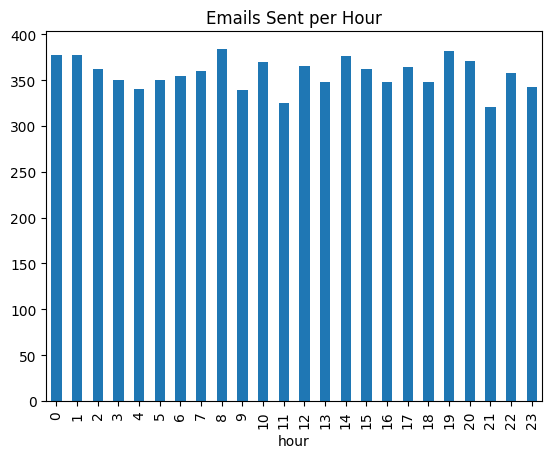

In [ ]:
#Time of Day Analysis

#Extract the hour from the timestamp and analyze trends.
#Extract the hour from the timestamp and analyze trends.

#The dataset's date column is converted to hours using .dt.hour.

#The .value_counts() method is used to count the frequency of each hour.

#.sort_index() ensures the hours are in ascending order.

#The results are visualized using a bar chart.

emails['hour'] = emails['date'].dt.hour
emails['hour'].value_counts().sort_index().plot(kind='bar', title='Emails Sent per Hour')

#This analysis helps identify peak email activity hours, which can be useful for optimizing email response strategies and understanding communication trends.

In [ ]:
#c. Average Emails per Day and Hour

#Compute daily and hourly averages.

emails_per_day = emails.resample('D', on='date').size()
print(emails_per_day)
print("Average Emails per Day:", emails_per_day.mean())

date
2025-01-15    226
2025-01-16    250
2025-01-17    288
2025-01-18    316
2025-01-19    292
2025-01-20    286
2025-01-21    276
2025-01-22    288
2025-01-23    268
2025-01-24    266
2025-01-25    315
2025-01-26    262
2025-01-27    270
2025-01-28    335
2025-01-29    271
2025-01-30    308
2025-01-31    273
2025-02-01    295
2025-02-02    305
2025-02-03    273
2025-02-04    284
2025-02-05    310
2025-02-06    278
2025-02-07    285
2025-02-08    311
2025-02-09    286
2025-02-10    265
2025-02-11    270
2025-02-12    279
2025-02-13    278
2025-02-14     65
Freq: D, dtype: int64
Average Emails per Day: 276.5806451612903


In [ ]:
from collections import Counter
import re

words = ' '.join(emails['content'].dropna()).lower()
word_counts = Counter(re.findall(r'\b[a-z]{3,}\b', words))
print("Most Common Words:", word_counts.most_common(10))


Most Common Words: [('the', 3661), ('urgent', 1250), ('response', 1250), ('needed', 1250), ('eod', 1250), ('please', 1227), ('find', 1227), ('invoice', 1227), ('attached', 1227), ('hope', 1225)]
